In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### 1. 데이터 로드

In [2]:
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

# 원본 특성만 사용 (엔지니어링된 특성 제외)
base_features = ['month', 'CO2ppm', 'Temp', 'Humid', 'VPD', 
                'Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car',
                'ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 
                'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']

# Leaf/Root ExtractionYield 제외 (타겟과 직접 관련)
X_original = df_merged[base_features].copy()

In [3]:
print(f"원본 특성만 사용: {X_original.shape[1]}개")

원본 특성만 사용: 19개


### 2. 타겟 변수 분석

In [4]:
print("타겟 변수 기초 통계:")
print(y_targets.describe())

타겟 변수 기초 통계:
         Leaf_TPC    Root_TPC    Leaf_TFC    Root_TFC
count  405.000000  405.000000  405.000000  405.000000
mean     7.708358    5.147294    4.670188    0.605360
std      0.506566    0.549619    2.575212    0.136367
min      6.247000    4.347000    1.199000    0.391000
25%      7.369000    4.678000    2.129000    0.492000
50%      7.814000    5.104000    5.242000    0.583000
75%      8.027000    5.293000    7.142000    0.694000
max      8.526000    6.396000    8.007000    0.861000


In [5]:
# 타겟 변수 간 상관관계
target_corr = y_targets.corr()
print(target_corr)

          Leaf_TPC  Root_TPC  Leaf_TFC  Root_TFC
Leaf_TPC  1.000000 -0.004297  0.549070  0.283821
Root_TPC -0.004297  1.000000  0.383635  0.855812
Leaf_TFC  0.549070  0.383635  1.000000  0.618493
Root_TFC  0.283821  0.855812  0.618493  1.000000


In [6]:
# 이상치 검사
for col in y_targets.columns:
    Q1 = y_targets[col].quantile(0.25)
    Q3 = y_targets[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((y_targets[col] < (Q1 - 1.5 * IQR)) | 
                (y_targets[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"{col}: {outliers}개 이상치")

Leaf_TPC: 9개 이상치
Root_TPC: 45개 이상치
Leaf_TFC: 0개 이상치
Root_TFC: 0개 이상치


### 3. 안전한 특성 엔지니어링

In [8]:
# 데이터 복사
X_engineered = X_original.copy()

In [9]:
# 1. 시나리오 인코딩 (원-핫 인코딩)
scenario = df_merged['scenario'].values
X_engineered['is_SSP1'] = (scenario == 'SSP1').astype(int)
X_engineered['is_SSP3'] = (scenario == 'SSP3').astype(int)
X_engineered['is_SSP5'] = (scenario == 'SSP5').astype(int)

In [10]:
# 2. 월별 성장 단계 (도메인 지식 기반)
X_engineered['growth_stage'] = X_engineered['month'].map({
    5: 1,  # 초기 성장
    6: 2,  # 중기 성장
    7: 3,  # 후기 성장
    8: 4,  # 성숙
    9: 5   # 수확기
})

In [11]:
# 3. 환경 스트레스 지표 (타겟과 무관한 특성만 사용)
X_engineered['temp_stress'] = np.abs(X_engineered['Temp'] - 22)  # 최적 온도 22도 가정
X_engineered['vpd_optimal'] = 1.0 / (1 + np.exp(X_engineered['VPD'] - 1.5))  # VPD 최적 1.5 가정

In [ ]:
# 4. 광합성 효율 비율 (타겟과 무관)
X_engineered['photosyn_efficiency'] = X_engineered['Fv-Fm'] / (X_engineered['Fv-Fm'].max() + 1e-10)
X_engineered['energy_dissipation'] = X_engineered['Dio-RC'] / (X_engineered['ABS-RC'] + 1e-10)

In [13]:
print(f"엔지니어링 후 특성 수: {X_engineered.shape[1]}")
print(f"추가된 특성: {X_engineered.shape[1] - X_original.shape[1]}개")

엔지니어링 후 특성 수: 27
추가된 특성: 8개


### 4. 시계열 분할 (더 보수적으로)

In [14]:
months = df_merged['month'].values

In [15]:
# 옵션 1: 보수적 분할
train_mask_v1 = months == 5  # 5월만 학습
val_mask_v1 = months == 6    # 6월 검증
test_mask_v1 = months >= 7   # 7-9월 테스트

In [16]:
# 옵션 2: 균형잡힌 분할  
train_mask_v2 = (months >= 5) & (months <= 6)  # 5-6월 학습
val_mask_v2 = months == 7                       # 7월 검증
test_mask_v2 = (months >= 8) & (months <= 9)   # 8-9월 테스트

In [17]:
print("옵션 1 (보수적):")
print(f"  Train (5월): {train_mask_v1.sum()}")
print(f"  Val (6월): {val_mask_v1.sum()}")
print(f"  Test (7-9월): {test_mask_v1.sum()}")

print("\n옵션 2 (균형):")
print(f"  Train (5-6월): {train_mask_v2.sum()}")
print(f"  Val (7월): {val_mask_v2.sum()}")
print(f"  Test (8-9월): {test_mask_v2.sum()}")

옵션 1 (보수적):
  Train (5월): 45
  Val (6월): 90
  Test (7-9월): 270

옵션 2 (균형):
  Train (5-6월): 135
  Val (7월): 93
  Test (8-9월): 177


In [18]:
# 균형잡힌 분할 사용
train_mask = train_mask_v2
val_mask = val_mask_v2
test_mask = test_mask_v2

### 5. 특성 선택

In [19]:
X_train = X_engineered[train_mask]
X_val = X_engineered[val_mask]
X_test = X_engineered[test_mask]

y_train = y_targets[train_mask]
y_val = y_targets[val_mask]
y_test = y_targets[test_mask]

In [20]:
# 상호 정보량 기반 특성 선택
mi_scores = []
for i in range(y_train.shape[1]):
    mi_score = mutual_info_regression(X_train, y_train.iloc[:, i], random_state=42)
    mi_scores.append(mi_score)

mi_scores_mean = np.mean(mi_scores, axis=0)
mi_feature_importance = pd.DataFrame({
    'feature': X_engineered.columns,
    'mi_score': mi_scores_mean
}).sort_values('mi_score', ascending=False)

print("상호 정보량 기반 중요 특성 TOP 10:")
print(mi_feature_importance.head(10))

상호 정보량 기반 중요 특성 TOP 10:
                feature  mi_score
2                  Temp  1.203029
4                   VPD  1.161845
24          vpd_optimal  1.154876
23          temp_stress  1.085714
26   energy_dissipation  0.989263
18                Fv-Fm  0.943855
11               ABS-RC  0.943297
8                   Car  0.941527
25  photosyn_efficiency  0.934379
13               Tro-RC  0.932554


In [21]:
# 상위 K개 특성 선택
K = min(20, X_engineered.shape[1])  # 최대 20개 특성
top_features = mi_feature_importance.head(K)['feature'].tolist()

X_train_selected = X_train[top_features]
X_val_selected = X_val[top_features]
X_test_selected = X_test[top_features]

print(f"\n선택된 특성 수: {K}개")


선택된 특성 수: 20개


### 6. 로버스트 스케일링

In [22]:
# RobustScaler는 이상치에 덜 민감
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)

### 7. 정규화된 모델로 검증

In [23]:
# Ridge 회귀 (L2 정규화)
ridge = Ridge(alpha=10.0)  # 강한 정규화
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_val_ridge = ridge.predict(X_val_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

print("Ridge 회귀 (α=10.0):")
print(f"  Train: MAE={mean_absolute_error(y_train, y_pred_train_ridge):.4f}, "
      f"R²={r2_score(y_train, y_pred_train_ridge):.4f}")
print(f"  Val:   MAE={mean_absolute_error(y_val, y_pred_val_ridge):.4f}, "
      f"R²={r2_score(y_val, y_pred_val_ridge):.4f}")
print(f"  Test:  MAE={mean_absolute_error(y_test, y_pred_test_ridge):.4f}, "
      f"R²={r2_score(y_test, y_pred_test_ridge):.4f}")

Ridge 회귀 (α=10.0):
  Train: MAE=0.1171, R²=0.9007
  Val:   MAE=0.2819, R²=-0.3861
  Test:  MAE=2.1677, R²=-85.4424


In [24]:
# RandomForest (제한된 복잡도)
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=5,          # 매우 얕은 트리
    min_samples_split=20, # 큰 최소 분할 샘플
    min_samples_leaf=10,  # 큰 최소 리프 샘플
    max_features='sqrt',  # 특성 서브샘플링
    random_state=42
)
rf.fit(X_train_scaled, y_train)

y_pred_train_rf = rf.predict(X_train_scaled)
y_pred_val_rf = rf.predict(X_val_scaled)
y_pred_test_rf = rf.predict(X_test_scaled)

print("\nRandomForest (제한된 복잡도):")
print(f"  Train: MAE={mean_absolute_error(y_train, y_pred_train_rf):.4f}, "
      f"R²={r2_score(y_train, y_pred_train_rf):.4f}")
print(f"  Val:   MAE={mean_absolute_error(y_val, y_pred_val_rf):.4f}, "
      f"R²={r2_score(y_val, y_pred_val_rf):.4f}")
print(f"  Test:  MAE={mean_absolute_error(y_test, y_pred_test_rf):.4f}, "
      f"R²={r2_score(y_test, y_pred_test_rf):.4f}")


RandomForest (제한된 복잡도):
  Train: MAE=0.0718, R²=0.9548
  Val:   MAE=0.2921, R²=-0.1422
  Test:  MAE=1.6656, R²=-42.0888


### 8. PCA 차원 축소 (선택적)

In [25]:
# 분산의 95% 설명하는 주성분 선택
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"주성분 수: {pca.n_components_}")
print(f"설명된 분산: {pca.explained_variance_ratio_.sum():.4f}")

주성분 수: 5
설명된 분산: 0.9645


In [26]:
# PCA 데이터로 Ridge 테스트
ridge_pca = Ridge(alpha=10.0)
ridge_pca.fit(X_train_pca, y_train)

y_pred_test_pca = ridge_pca.predict(X_test_pca)

print(f"\nPCA + Ridge:")
print(f"  Test: MAE={mean_absolute_error(y_test, y_pred_test_pca):.4f}, "
      f"R²={r2_score(y_test, y_pred_test_pca):.4f}")


PCA + Ridge:
  Test: MAE=2.0767, R²=-71.0447


### 9. 최종 전처리 데이터 저장

In [27]:
# 전체 데이터에 대해 적용
X_final = X_engineered[top_features].copy()

In [28]:
# 각 모델용 데이터 생성
# Linear
X_linear_final = X_final.copy()

# Neural Network (전체 데이터로 스케일러 재학습)
scaler_final = RobustScaler()
X_nn_final = pd.DataFrame(
    scaler_final.fit_transform(X_final),
    columns=X_final.columns
)

# Tree
X_tree_final = X_final.copy()

# 저장
X_linear_final.to_csv('X_preprocessed_linear_final.csv', index=False)
X_nn_final.to_csv('X_preprocessed_nn_final.csv', index=False)
X_tree_final.to_csv('X_preprocessed_tree_final.csv', index=False)

In [29]:
# 메타 정보 저장
meta_info = {
    'selected_features': top_features,
    'n_features': len(top_features),
    'scaler_type': 'RobustScaler',
    'train_months': [5, 6],
    'val_months': [7],
    'test_months': [8, 9]
}

import json
with open('preprocessing_metadata.json', 'w') as f:
    json.dump(meta_info, f, indent=2)
print("✓ preprocessing_metadata.json")

✓ preprocessing_metadata.json


### 10. 시각화

Text(0.5, 1.0, 'Residual Plot')

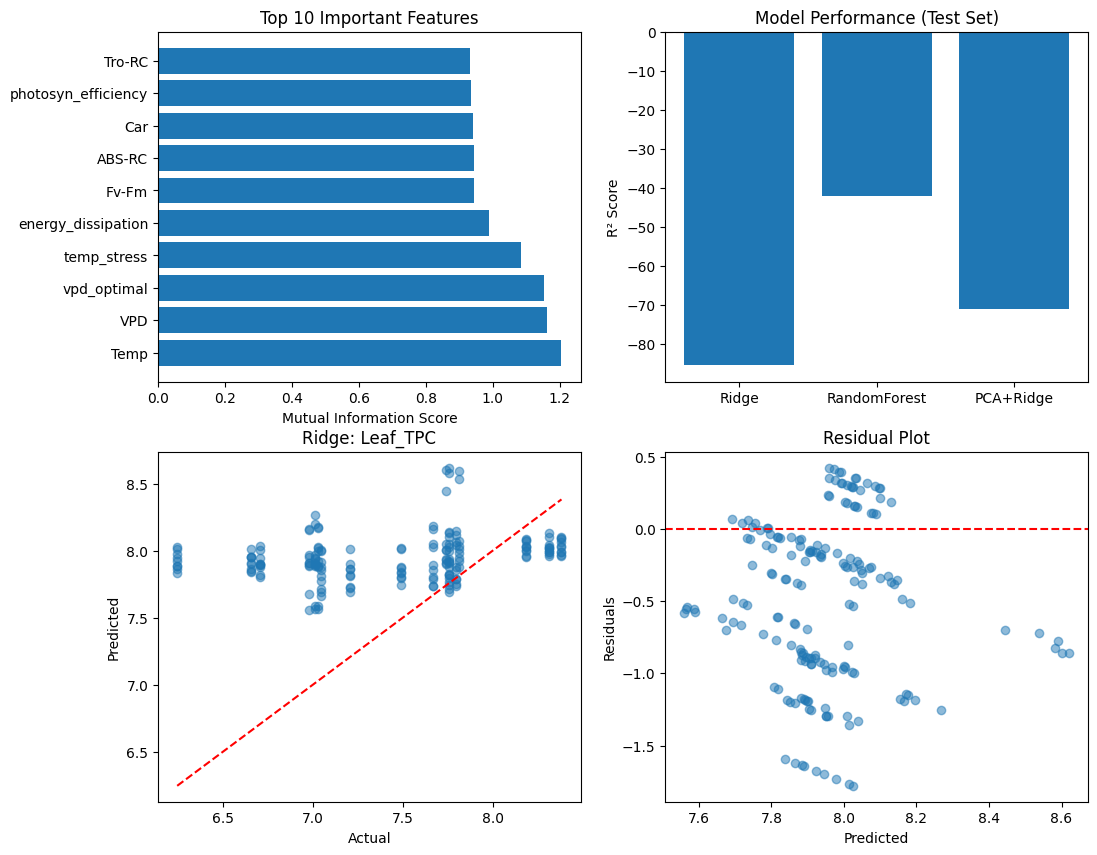

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 특성 중요도
ax = axes[0, 0]
top_10_features = mi_feature_importance.head(10)
ax.barh(range(10), top_10_features['mi_score'].values)
ax.set_yticks(range(10))
ax.set_yticklabels(top_10_features['feature'].values)
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 10 Important Features')

# 2. 모델 성능 비교
ax = axes[0, 1]
models = ['Ridge', 'RandomForest', 'PCA+Ridge']
test_r2 = [r2_score(y_test, y_pred_test_ridge),
           r2_score(y_test, y_pred_test_rf),
           r2_score(y_test, y_pred_test_pca)]
ax.bar(models, test_r2)
ax.set_ylabel('R² Score')
ax.set_title('Model Performance (Test Set)')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 3. 예측 vs 실제 (Ridge)
ax = axes[1, 0]
ax.scatter(y_test.iloc[:, 0], y_pred_test_ridge[:, 0], alpha=0.5)
ax.plot([y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()],
        [y_test.iloc[:, 0].min(), y_test.iloc[:, 0].max()], 'r--')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Ridge: {y_targets.columns[0]}')

# 4. 잔차 플롯
ax = axes[1, 1]
residuals = y_test.iloc[:, 0] - y_pred_test_ridge[:, 0]
ax.scatter(y_pred_test_ridge[:, 0], residuals, alpha=0.5)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_xlabel('Predicted')
ax.set_ylabel('Residuals')
ax.set_title('Residual Plot')